In [1]:
#importation de base
import pandas as pd
import os , sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns",None)
sys.path.append(os.path.abspath("C:/Users/kamto/OneDrive/Desktop/ed/projet-data-ecommerce/retail-data-projet"))

In [2]:
#Chargement de la dataset CSV et lecture du header
DATA_PATH = "../data/data.csv"
df = pd.read_csv(DATA_PATH,encoding = "latin1") #convertir en encodage utf8

In [3]:
from src.cleaning import clean_data

#cleaning Data
df_clean = clean_data(df)
df.shape,df_clean.shape

((541909, 8), (534129, 9))

In [4]:
#percentage of missing data
df_clean.isna().mean() * 100


InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
is_returned    0.0
dtype: float64

In [5]:
#cleaned data description
df_clean.describe(include='all')


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_returned
count,534129,534129,534129,534129.000000,534129,534129.000000,534129,534129,534129
unique,23796,3938,4042,NaN,NaN,NaN,4372,38,2
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,unknown,United Kingdom,False
freq,1114,2295,2353,NaN,NaN,NaN,132565,487806,524878
mean,NaN,NaN,NaN,8.581521,2011-07-04 12:02:01.631403776,3.337006,NaN,NaN,NaN
min,NaN,NaN,NaN,-36.000000,2010-12-01 08:26:00,0.550000,NaN,NaN,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:36:00,1.250000,NaN,NaN,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 15:55:00,2.100000,NaN,NaN,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-18 17:10:00,4.130000,NaN,NaN,NaN
max,NaN,NaN,NaN,100.000000,2011-12-09 12:50:00,24.960000,NaN,NaN,NaN


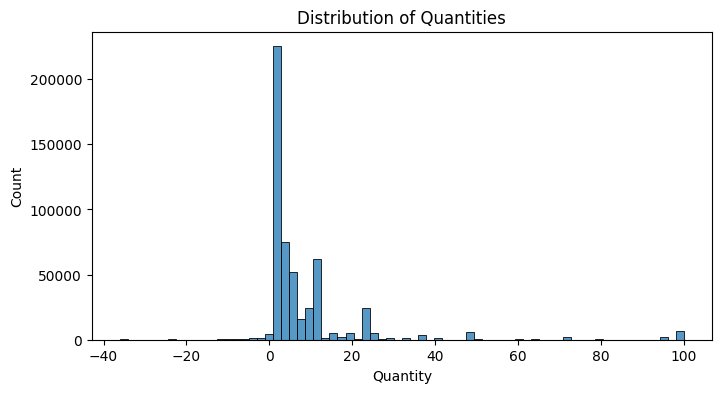

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(df_clean["Quantity"],bins=70)
plt.title("Distribution of Quantities")
plt.show()

the distribution of quantities is right-skewed.most transactions involve small quantities, which id typical behaviour of B2C behavior. negative quantities likely represent product returns or order cancellations, while very large quantities suggest bulk purchases or B2B clients

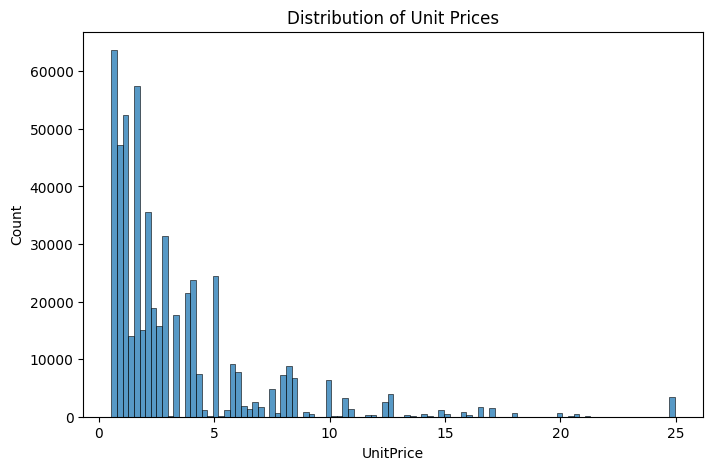

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["UnitPrice"],bins=100)
plt.title("Distribution of Unit Prices")
plt.xlabel("UnitPrice")
plt.ylabel("Count")
plt.show()


In [12]:
#Chiffre d'affaire (data's revenue)
df_clean["Revenue"] = df_clean["UnitPrice"] * df_clean["Quantity"]
df_clean["Revenue"].describe()

count    534129.000000
mean         16.930638
std          34.392646
min        -459.000000
25%           3.750000
50%           9.950000
75%          17.700000
max        2080.000000
Name: Revenue, dtype: float64

In [14]:
# Top 10 produit par chiffre d'affaire
top_products = (
    df_clean.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)
top_products


Description
REGENCY CAKESTAND 3 TIER              159220.16
PARTY BUNTING                          94985.30
WHITE HANGING HEART T-LIGHT HOLDER     79237.28
JUMBO BAG RED RETROSPOT                74692.28
POSTAGE                                57589.54
PAPER CHAIN KIT 50'S CHRISTMAS         51609.26
CHILLI LIGHTS                          47361.62
ASSORTED COLOUR BIRD ORNAMENT          47204.14
RABBIT NIGHT LIGHT                     41436.15
SPOTTY BUNTING                         40020.89
JUMBO BAG PINK POLKADOT                35135.91
JAM MAKING SET WITH JARS               34715.14
LUNCH BAG RED RETROSPOT                34601.66
SET OF 3 CAKE TINS PANTRY DESIGN       33306.47
CHOCOLATE HOT WATER BOTTLE             32328.70
DOORMAT KEEP CALM AND COME IN          32259.51
HOT WATER BOTTLE TEA AND SYMPATHY      30687.06
JUMBO STORAGE BAG SUKI                 30130.12
VICTORIAN GLASS HANGING T-LIGHT        29308.56
PAPER CHAIN KIT VINTAGE CHRISTMAS      28857.54
Name: Revenue, dtype: float6